# Notebook 3 — Fast and Robust, in Practice

Notebooks 1-2 established the theory and the motivation. This notebook runs the
actual, already-verified `ccf_pipeline` on **real seismic data** — mostly
Madagascar `XV` pairs from this project's own 380-pair batch (`AF.SKRH`–`XV.BAND`,
`XV.BITY`–`XV.MAGY`), with `MTAN`/`RUNG` and `SA53`/`SA58` (Tanzania, within
ADAMA's Africa coverage) for the harder-pair investigation in Section 2.

| Section | What it does | Status |
|---|---|---|
| 1. Four techniques, one pair | `AF.SKRH`–`XV.BAND`: single-taper / `Mspec` / `MspecBestK` / `FastMspec` side by side — coherence, isolated runtime + peak memory, and whether each yields a pickable curve (1); the K-sweep (1b); and why `FastMspec`'s cost stays flat as NW grows while classical multitaper's climbs (1c) | Cross-spectra precomputed on bluehive (`verification/nb3_technique_cost/`); picking + plotting live |
| 2. Does the cleaner coherence give a better curve? | `XV.BITY`–`XV.MAGY` (2a): single-taper vs `FastMspec` coherence + the seislib picker's own view. Then `MTAN`/`RUNG` (2b-2d): a marginal pair where the report's time-domain SNR metric comes out backwards, and the investigation into why | 2b needs N/E->R/T rotation, which doesn't exist elsewhere in this codebase (callout before that section) |
| 3. Synthetic NLNM PSD stability | Reproduces the report's Fig. 2 (single- vs. multi-taper stability on a synthetic NLNM-spectrum signal) | New implementation, controlled bridge to Notebook 1's Figs 4-6 |


In [1]:
import sys
sys.path.insert(0, '../python')
sys.path.insert(0, '.')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ccf_pipeline.prepare_data import prepare_station_pair
from ccf_pipeline import preprocessing as pp
from ccf_pipeline.crosscorr_mtc import (
    compute_crosscorr_mtc_fastmspec, compute_crosscorr_mtc_mspec, compute_crosscorr_mtc_mspecbestk,
)
from ccf_pipeline.dispatch import compute_crosscorr, FilterConfig
from ccf_pipeline.fast_cross_spectrum import fast_spectrum_batch
from thomson_multitaper import FastMultitaper
from _lib.nb3_helpers import (
    calc_snr_onesided, prepare_transverse_pair, nlnm_synthetic, bessel_leakage_test_signal,
)

DATA = Path('../data/raw_data')
META = Path('../data/metadata')
plt.rcParams['figure.dpi'] = 100


## 1. One pair, four techniques: what each costs, and what it buys

Station pair `AF.SKRH`–`XV.BAND` (290 km, Madagascar) is this project's
longest-running real-data test case: the pair the vendored/instrumented picker
was first validated against (`verification/skrh_band_real_data/`), the pair the
`ADAMA_gvib.h5` raw-trace loader was validated against
(`verification/gvib_skrh_band_test/`), and one of the 380 pairs in the full
bluehive batch. So it's the natural place to put all four cross-spectrum
techniques side by side on the same real windows.

The question isn't "does each technique reproduce itself." It's the practical
one: fed into the dispersion-curve picker (Notebook 4), **which technique's
coherence spectrum actually yields a pickable curve — and what does it cost in
runtime and memory to get there?** The four: single-taper (the legacy
codebase's approach), classical multitaper (`Mspec`, K≈80 — this project's
deliberately heavy baseline), `MspecBestK` (Karnik et al.'s taper count, K≈13,
but classical averaging), and `FastMspec` (Karnik, Romberg & Davenport 2022's
actual fused algorithm — Notebook 1's paper).

The cross-spectra were computed once on bluehive — they need the full ~250 MB
matched-data arrays, and `Mspec` at the batch K=80 runs ~10 min at ~12 GB. Each
technique ran in **its own process**, so the peak-memory numbers are clean:
`ru_maxrss` is a whole-process high-water mark, and running techniques
back-to-back in one process lets later ones hide behind the first one's mark
(the trap the earlier version of this section had to write three paragraphs
around). Each technique uses its production config: single-taper is
detrend + 5% cosine taper + plain FFT; `MspecBestK` and `FastMspec` use
`Wband=0.001` (NW≈10.8 at N=10801); `Mspec` uses the batch pipeline's fixed
NW=100 / K=80.

In [2]:
# Section 1 precompute -- 4 coherence spectra + isolated runtime/peak memory for AF.SKRH-XV.BAND,
# built from ADAMA_gvib.h5. Scripts + full provenance: verification/nb3_technique_cost/
# (driver_sec1.py runs on bluehive in the fastmspec_batch env; sec1b = the K-sweep below).
NB3 = Path('../data/results/dispcurve_quality/nb3_precompute')
sec1 = np.load(NB3 / 'nb3_sec1_skrh.npz')
sec1_metrics = pd.read_json(NB3 / 'nb3_sec1_metrics.json')

N_SAMPLES = 10801  # 3-hour window at dt=1 s -- the production window length throughout this project
freq1 = sec1['freq']
dist_skrh = float(sec1['dist_km'])
TECHS = ['single_taper', 'MspecBestK', 'FastMspec', 'Mspec']
LABEL = {'single_taper': 'single-taper', 'MspecBestK': 'MspecBestK', 'FastMspec': 'FastMspec', 'Mspec': 'Mspec'}
coh1 = {t: sec1[f'coh_{t}'] for t in TECHS}


def sec1_row(technique_label):
    return sec1_metrics[(sec1_metrics.section == 'sec1') & (sec1_metrics.technique == technique_label)].iloc[0]

print(f"AF.SKRH-XV.BAND, {dist_skrh:.1f} km, coh_num={int(sec1['coh_num'])} "
      f"(built from ADAMA_gvib.h5; Stage 3 reference: 290.3 km, 1605 traces)")
sec1_metrics[sec1_metrics.section == 'sec1'][['technique', 'nw_label', 'taper_size', 'runtime_s', 'peak_mem_mb']]


AF.SKRH-XV.BAND, 289.2 km, coh_num=1620 (built from ADAMA_gvib.h5; Stage 3 reference: 290.3 km, 1605 traces)


,technique,nw_label,taper_size,runtime_s,peak_mem_mb
0,single-taper,NW_prod(~10.8),1,3.9,1701.1
1,MspecBestK,NW_prod(~10.8),15,112.3,10909.6
2,FastMspec,NW_prod(~10.8),13,137.1,17183.9
3,Mspec,NW=100 (batch baseline),80,563.9,11708.8


### Run the picker on each

Same picker, same per-pair hybrid ADAMA+GDM52 reference curve as Notebook 4
(`hybrid_reference_curve.py`), a coarse 9-template corridor scan — applied to
each technique's coherence in turn. SKRH-BAND is a genuinely marginal pair (it
sits near the far edge of quartile 1), so this is a demanding test.

In [3]:
from dispcurve_pick.hybrid_reference_curve import AdamaMap, Gdm52Map, build_reference_curve
from dispcurve_pick import build_template_family_widened
from _lib.nb4_helpers import scan_templates_with_picker, best_of

mdg = pd.read_csv(DATA / 'madagascar' / 'madagascar_stn_conn_ccflist.csv')
rs = mdg[(mdg.stn1 == 'SKRH') & (mdg.stn2 == 'BAND')].iloc[0]
adama = AdamaMap('../data/reference/adama_maps'); gdm52 = Gdm52Map('../data/reference/gdm52')
hyb_skrh = build_reference_curve(float(rs.stn1lat), float(rs.stn1lon), float(rs.stn2lat), float(rs.stn2lon),
                                 sources=[adama, gdm52], wave='love')
templates = build_template_family_widened(hyb_skrh.func, hyb_skrh.f_lo, hyb_skrh.f_hi,
                                          corridor_km_s=0.8, step_km_s=0.2)

pick1 = {}
for t in TECHS:
    scanned = scan_templates_with_picker(freq1, coh1[t], dist_skrh, templates,
                                         hyb_skrh.f_lo, hyb_skrh.f_hi, 1.2, 4.8, verbose=False)
    delta, curve, picks, diag = best_of(scanned)
    pick1[t] = diag
    if diag is None:
        print(f"{LABEL[t]:>13}: no template converged")
    else:
        print(f"{LABEL[t]:>13}: converged, delta={delta:+.2f} km/s, "
              f"coverage={diag.freq_coverage_fraction:.2f}, bad_quality={diag.bad_quality_fraction:.2f}")


 single-taper: no template converged


   MspecBestK: no template converged


    FastMspec: converged, delta=-0.40 km/s, coverage=0.20, bad_quality=0.88


        Mspec: no template converged


### The picture

Real part of the coherence for each technique over the full band, with the
reference curve's own predicted zero-crossings marked as ticks — where a
Bessel $J_0$ coherency *should* cross zero for this path.

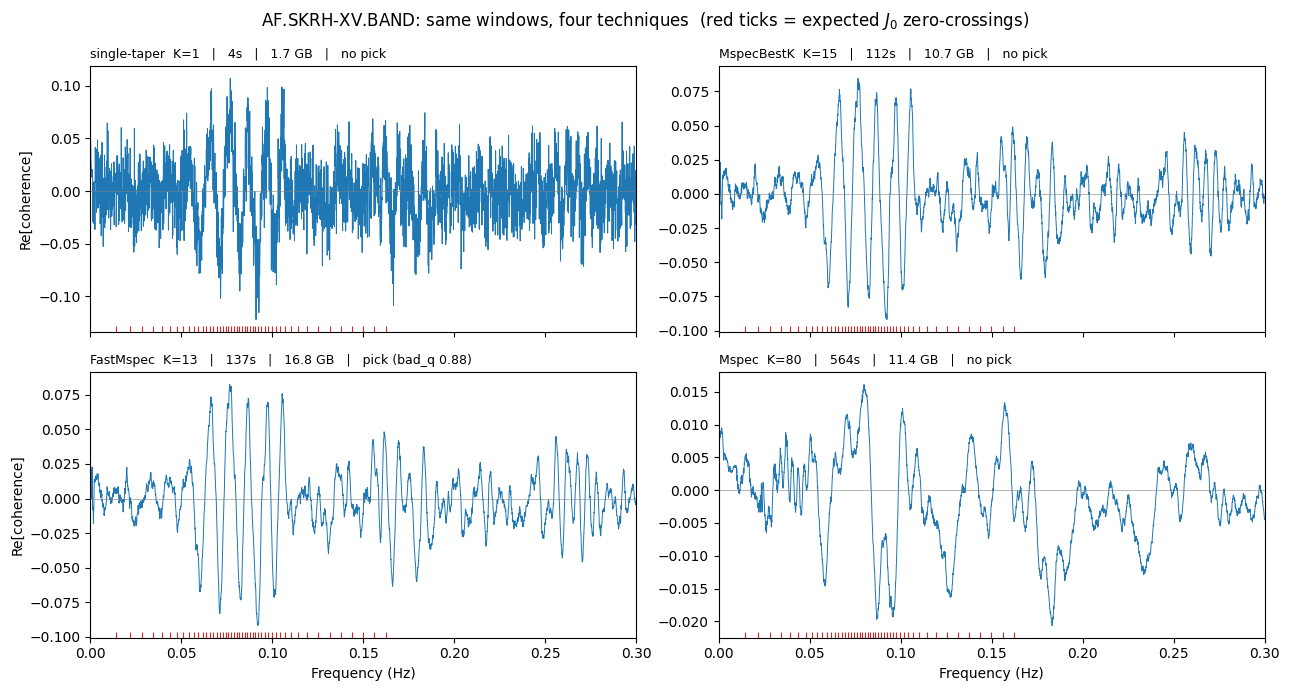

In [4]:
from scipy.special import j0

fpred = np.linspace(hyb_skrh.f_lo, hyb_skrh.f_hi, 4000)
bpred = j0(2 * np.pi * fpred * dist_skrh / hyb_skrh.func(fpred))
zx = fpred[:-1][np.diff(np.sign(bpred)) != 0]

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
band1 = freq1 <= 0.30
for ax, t in zip(axes.flat, TECHS):
    ax.plot(freq1[band1], coh1[t][band1], lw=0.7, color='C0')
    ax.axhline(0, color='gray', lw=0.4)
    ax.vlines(zx, -0.02, 0.02, transform=ax.get_xaxis_transform(), color='C3', lw=0.8)
    m = sec1_row(LABEL[t]); d = pick1[t]
    verdict = 'no pick' if d is None else f"pick (bad_q {d.bad_quality_fraction:.2f})"
    ax.set_title(f"{LABEL[t]}  K={int(m.taper_size)}   |   {m.runtime_s:.0f}s   |   "
                 f"{m.peak_mem_mb / 1024:.1f} GB   |   {verdict}", fontsize=9, loc='left')
    ax.set_xlim(0, 0.30)
for ax in axes[1]:
    ax.set_xlabel('Frequency (Hz)')
for ax in axes[:, 0]:
    ax.set_ylabel('Re[coherence]')
plt.suptitle('AF.SKRH-XV.BAND: same windows, four techniques  (red ticks = expected $J_0$ zero-crossings)')
plt.tight_layout()
plt.show()


In [5]:
base_rt = sec1_row('single-taper').runtime_s
rows = []
for t in TECHS:
    m = sec1_row(LABEL[t]); d = pick1[t]
    rows.append({'Technique': LABEL[t], 'K': int(m.taper_size), 'Runtime (s)': round(m.runtime_s),
                 'x single-taper': round(m.runtime_s / base_rt, 1),
                 'Peak mem (GB)': round(m.peak_mem_mb / 1024, 1),
                 'Pickable curve?': 'no' if d is None else 'yes',
                 'bad_quality': None if d is None else round(d.bad_quality_fraction, 2),
                 'coverage': None if d is None else round(d.freq_coverage_fraction, 2)})
pd.DataFrame(rows)


,Technique,K,Runtime (s),x single-taper,Peak mem (GB),Pickable curve?,bad_quality,coverage
0,single-taper,1,4,1.0,1.7,no,NaN,NaN
1,MspecBestK,15,112,28.8,10.7,no,NaN,NaN
2,FastMspec,13,137,35.2,16.8,yes,0.88,0.2
3,Mspec,80,564,144.6,11.4,no,NaN,NaN


Reading across the panels and the table:

- **single-taper** is cheapest by far and produces no pickable curve — a
  noise-dominated spectrum with hundreds of spurious sign changes. At full
  dataset scale it converges on **0 of 380** pairs (Notebook 4, Section 1);
  this is that result on one pair, made visible.
- **`Mspec`** (NW=100, K=80 — the batch pipeline's fixed classical baseline)
  costs the most (~5× single-taper) and its wide smoothing bandwidth washes the
  oscillations flat: its coherence amplitude is ~5× smaller than the others' and
  the real zero-crossings are blurred through, so the picker has nothing to
  track. Expensive *and* over-smoothed — it converges on 15% of the 380 pairs
  vs. FastMspec's 26%.
- **`MspecBestK`** and **`FastMspec`** (both K≈13–15) produce nearly identical
  coherence — same clean oscillation tracking the expected zero-crossings. On
  this hard pair and this coarse scan, only `FastMspec` locks onto a curve (a
  marginal one — coverage ~0.2); `MspecBestK`'s best template just misses the
  convergence test. Their coherence is the same; the cost is nearly the same
  (`FastMspec` is a touch slower and heavier here — ~137 s / 17 GB vs
  ~112 s / 11 GB). Section 2 shows what a *clean* pick looks like, on the
  sweep's best example.

So at this project's bandwidth the honest story is: single-taper is cheap and
unusable, `Mspec` is expensive and over-smoothed, and `MspecBestK` and
`FastMspec` give the same (usable) coherence at a similar cost — with
`FastMspec` the one that actually converged here. What makes `FastMspec` the
robust *default* rather than a coin-flip with `MspecBestK` is that its cost
doesn't move when the bandwidth does. Section 1c.

### 1b. How many tapers do you actually need?

Section 1 fixed each technique's K. This sweeps classical `Mspec`'s taper count
directly — same bandwidth product NW, so resolution is held fixed — to see
(i) how fast the coherence estimate's roughness stabilises and (ii) what runtime
and memory do over the same range. Same SKRH-BAND data, same one-process-per-run
measurement, precomputed on bluehive (`verification/nb3_technique_cost/`).

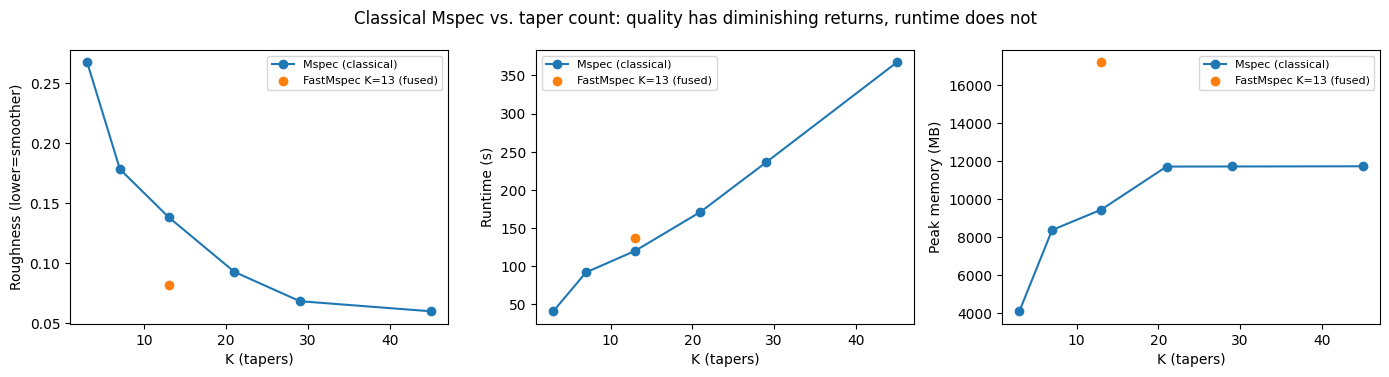

,k_taps,roughness,runtime_s,peak_mem_mb,peak_mem_GB
0,3,0.2671,40.7,4102.3,4.0
1,7,0.1782,91.7,8373.5,8.2
2,13,0.1380,119.9,9442.6,9.2
3,21,0.0927,171.0,11710.4,11.4
4,29,0.0683,235.8,11714.6,11.4
5,45,0.0599,367.0,11725.2,11.5


In [6]:
ksweep = pd.read_json(NB3 / 'nb3_sec1b_ksweep.json').sort_values('k_taps')


def roughness(est, f, lo=0.0, hi=0.4):
    """Bin-to-bin 2nd-difference smoothness, normalised by in-band RMS -- a
    scale-invariant leakage/variance proxy; lower = smoother."""
    b = (f >= lo) & (f < hi); e = est[b]
    return float(np.mean(np.abs(e[2:] - 2 * e[1:-1] + e[:-2])) / np.sqrt(np.mean(e ** 2)))


fm = sec1_row('FastMspec')
fm_rough = roughness(coh1['FastMspec'], freq1)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, col, lab in zip(axes, ['roughness', 'runtime_s', 'peak_mem_mb'],
                        ['Roughness (lower=smoother)', 'Runtime (s)', 'Peak memory (MB)']):
    ax.plot(ksweep.k_taps, ksweep[col], 'o-', color='C0', label='Mspec (classical)')
    yfm = {'roughness': fm_rough, 'runtime_s': fm.runtime_s, 'peak_mem_mb': fm.peak_mem_mb}[col]
    ax.scatter([fm.taper_size], [yfm], color='C1', zorder=5, label=f'FastMspec K={int(fm.taper_size)} (fused)')
    ax.set_xlabel('K (tapers)'); ax.set_ylabel(lab); ax.legend(fontsize=8)
plt.suptitle('Classical Mspec vs. taper count: quality has diminishing returns, runtime does not')
plt.tight_layout()
plt.show()
ksweep[['k_taps', 'roughness', 'runtime_s', 'peak_mem_mb']].assign(
    peak_mem_GB=lambda d: (d.peak_mem_mb / 1024).round(1))


Roughness falls fastest through K≈13 — the natural taper count here is
about `2NW−1 ≈ 21` — then keeps improving with clearly diminishing returns.
Runtime rises roughly linearly with K the whole way (classical averaging
materialises every taper). Memory rises too, then flattens once the K-axis
chunking pass caps it — that cap is engineering this project had to add, not
something the algorithm gives you for free. `FastMspec`'s fused point (orange)
sits near the classical curve on all three axes at this K; its real advantage
isn't visible until NW grows, which is Section 1c.


### 1c. Why `FastMspec`'s cost doesn't climb with NW

`FastMultitaper` (Karnik, Romberg & Davenport 2022 — Notebook 1's paper)
doesn't multiply the data by all K DPSS tapers and average. It splits the
multitaper average into a single FFT-based sinc-kernel convolution that
analytically stands in for *every* well-concentrated taper at once (`O(N log N)`,
never materialised), plus an explicit correction over only the tapers in the
DPSS eigenvalue *transition region*. The code calls that count `r` — a property
of how wide the transition band is, not of K.

In [7]:
pd.DataFrame([{'NW': nw,
               'K (classical taper count)': (fmt := FastMultitaper(10801, nw / 10801, 1 - 1e-5, 1e-5)).K,
               'r (FastMspec correction)': fmt.r, 'r / K': f'{100 * fmt.r / fmt.K:.0f}%'}
              for nw in [5, 10.8, 20, 50, 100, 200, 400]])


,NW,K (classical taper count),r (FastMspec correction),r / K
0,5.0,5,11,220%
1,10.8,15,13,87%
2,20.0,33,14,42%
3,50.0,92,16,17%
4,100.0,191,18,9%
5,200.0,390,20,5%
6,400.0,790,20,3%


`r` stays bounded (≈11–20) across two orders of magnitude of NW while K
grows linearly — verified to NW=1600 elsewhere in the project. And `r`, `K` both
depend only on the *product* NW, not on N and W separately: at fixed NW they're
identical whether N=10801 or N=86401. So whatever bandwidth Stage 5 lands on,
`FastMspec`'s cost structure keeps the same shape.

**Measured, not just counted.** The same SKRH-BAND cross-spectrum recomputed for
`FastMspec` and `MspecBestK` — the two bandwidth-tracking techniques — across NW
from production (10.8) up to this pair's own resolution ceiling
`NW_high = N·c_min/(4R)`: the widest NW at which the smoothing bandwidth `2W`
still fits inside the Bessel zero-crossing spacing `c_min/2R`.

SKRH-BAND: hybrid-curve min = 1.60 km/s (unphysically low at short period); c_min floored to 3.0 km/s
R = 289 km  ->  NW_high = 28.0   (production NW = 10.8, inside; NW=40 below is past it -- a cost probe)


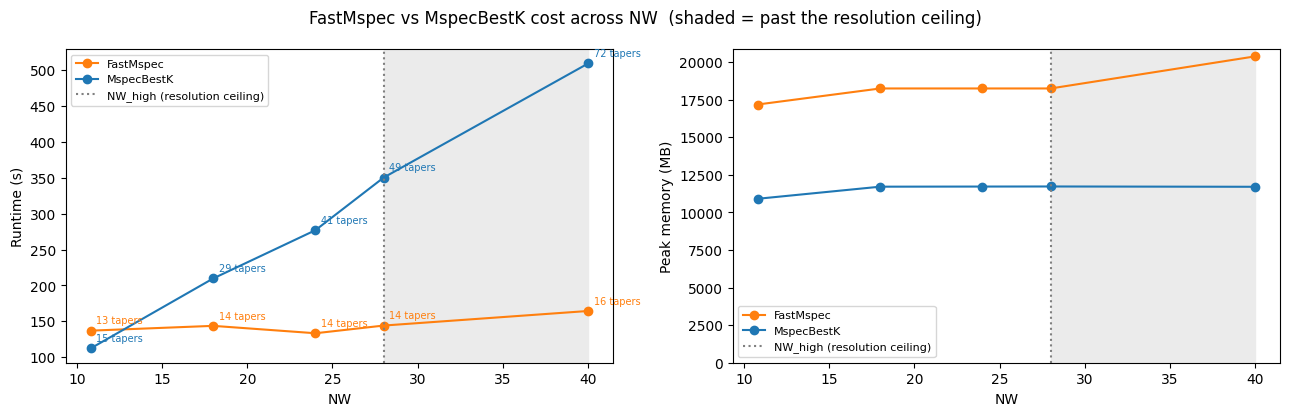

,technique,nw,tapers_formed,runtime_s,mem_GB
1,MspecBestK,10.801,15,112.3,10.7
2,FastMspec,10.801,13,137.1,16.8
4,FastMspec,18.000,14,143.8,17.8
5,MspecBestK,18.000,29,209.8,11.4
6,FastMspec,24.000,14,133.5,17.8
7,MspecBestK,24.000,41,277.0,11.4
8,FastMspec,28.000,14,144.2,17.8
9,MspecBestK,28.000,49,350.2,11.5
10,FastMspec,40.000,16,164.5,19.9
11,MspecBestK,40.000,72,509.1,11.4


In [8]:
# c_min for the resolution ceiling. The hybrid curve's short-period end (T < 12 s, flagged
# low_confidence) dips to ~1.5 km/s -- unphysical for Love-wave phase velocity, a known ADAMA
# short-period limitation (data/reference/hybrid_curve_README.md). Floor c_min at 3.0 km/s,
# a hard physical lower bound for continental Love waves.
c_min_raw = float(np.min(hyb_skrh.func(np.linspace(hyb_skrh.f_lo, hyb_skrh.f_hi, 400))))
c_min_skrh = max(3.0, c_min_raw)
nw_high_skrh = N_SAMPLES * c_min_skrh / (4 * dist_skrh)
print(f"SKRH-BAND: hybrid-curve min = {c_min_raw:.2f} km/s (unphysically low at short period); "
      f"c_min floored to {c_min_skrh:.1f} km/s")
print(f"R = {dist_skrh:.0f} km  ->  NW_high = {nw_high_skrh:.1f}   "
      f"(production NW = {0.001 * N_SAMPLES:.1f}, inside; NW=40 below is past it -- a cost probe)")

cost = (sec1_metrics[sec1_metrics.technique.isin(['FastMspec', 'MspecBestK']) & sec1_metrics.error.isna()]
        .sort_values('nw'))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, col, lab in zip(axes, ['runtime_s', 'peak_mem_mb'], ['Runtime (s)', 'Peak memory (MB)']):
    for tech, c in [('FastMspec', 'C1'), ('MspecBestK', 'C0')]:
        sub = cost[cost.technique == tech]
        ax.plot(sub.nw, sub[col], 'o-', color=c, label=tech)
        if col == 'runtime_s':
            for _, r in sub.iterrows():
                ax.annotate(f"{int(r.taper_size)} tapers", (r.nw, r[col]), textcoords='offset points',
                            xytext=(4, 5), fontsize=7, color=c)
    ax.axvline(nw_high_skrh, color='gray', ls=':', label='NW_high (resolution ceiling)')
    ax.axvspan(nw_high_skrh, cost.nw.max(), color='0.92', zorder=0)
    ax.set_xlabel('NW'); ax.set_ylabel(lab); ax.legend(fontsize=8)
axes[1].set_ylim(0, None)
plt.suptitle('FastMspec vs MspecBestK cost across NW  (shaded = past the resolution ceiling)')
plt.tight_layout()
plt.show()

cost.assign(tapers_formed=cost.taper_size, mem_GB=(cost.peak_mem_mb / 1024).round(1))[
    ['technique', 'nw', 'tapers_formed', 'runtime_s', 'mem_GB']]


**Runtime is where it shows.** Both techniques are handed the same NW,
which implies the same nominal taper count K (the `r`/`K` table above: ~15 at
NW=10.8, ~49 at NW=28). `MspecBestK` forms all K and averages them, so its
runtime climbs with K (~112 s → ~350 s from production to the ceiling).
`FastMspec` forms only the `r` transition-region tapers (~14, flat) — that's the
`tapers_formed` column above — so its runtime holds at ~135–145 s. They cross
just above production NW: `MspecBestK` is slightly cheaper at NW≈10.8,
`FastMspec` is decisively cheaper by NW≈18, and 3× cheaper at NW=40.

**Memory** tells the architectural half of the story. `MspecBestK` stays ~12 GB
across the whole sweep — but only because of the K-axis chunking pass this project
had to add (its NW=100 / K=80 classical baseline hit a wall at real Madagascar
trace counts). `FastMspec` sits a bit *higher* (~18 GB, the `O(N log N)`
sinc-convolution term) but flat by construction — nothing in it ever scaled with
K, so nothing had to be capped.

So the honest summary: at today's NW≈10.8 `FastMspec` is not dramatically cheaper
than `MspecBestK` — the gap is real but modest, and it even costs a little more
memory. The durable claim is that `FastMspec`'s cost was verified flat across NW
5–1600 with no conditional engineering, where classical multitaper needed a
dedicated fix once and would need attention again if Stage 5 raises the bandwidth.


### 1d. Why multitaper at all?

Sections 1, 1b, and 1c compared multitaper *techniques* against each other.
Whether multitaper is worth using **at all**, compared to the legacy
codebase's much simpler single-taper approach, is answered directly and at
full dataset scale in **Notebook 4, Section 1** -- single-taper's real-data
dispersion-curve convergence rate across all 380 pairs is 0%, not low, zero,
while `FastMspec` converges on roughly a quarter of them. That's the
headline "is it worth the compute cost" answer this notebook's own
technique-vs-technique comparisons (above) build toward, at a scale this
notebook doesn't itself need to reproduce.


## 2. Does the cleaner coherence give a better dispersion curve?

Section 1 showed `FastMspec` produces a pickable coherence spectrum where
single-taper produces noise. This section makes that concrete — first on the
strongest example from the revamp's own testing (the 380-pair batch and the
NW-sweep), then on a harder pair where the report's time-domain SNR metric can
point the wrong way.

### 2a. XV.BITY–XV.MAGY: coherence, and the curve it yields

`XV.BITY`–`XV.MAGY` (223 km, Madagascar) is the quartile-1 representative pair
from the revamp's 300-point NW-sweep — a clean, long-tracked `FastMspec` pick
(`docs/round2_hypothesis_evaluation.tex`, §8). Same matched data and
`ADAMA_gvib.h5` source as Section 1; the FastMspec (NW≈22.2, the sweep's
best-converging bandwidth for this pair) and single-taper cross-spectra were
precomputed on bluehive (`verification/nb3_technique_cost/`); picking and
plotting are live here.

XV.BITY-XV.MAGY, 223.1 km  |  FastMspec K=14, coh_num=1995  |  single-taper coh_num=1995


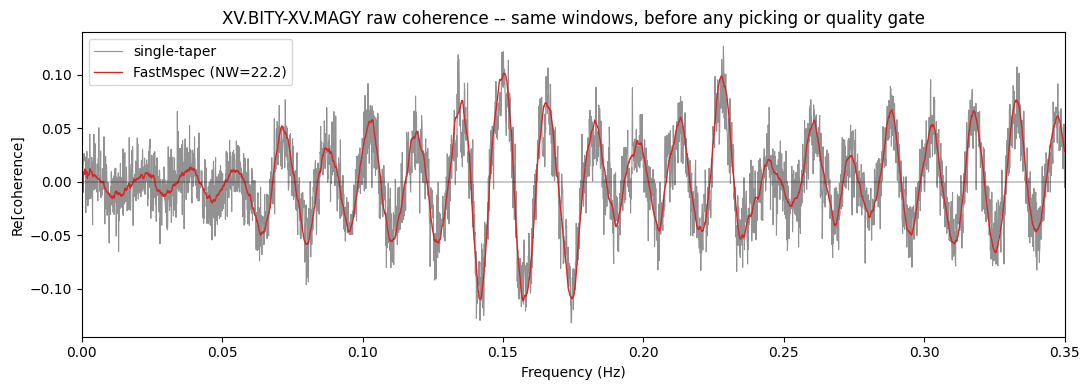

In [9]:
sec2 = np.load(NB3 / 'nb3_sec2_bity_magy.npz')
f2 = sec2['freq']
coh_fm, coh_st = sec2['coh_fastmspec'], sec2['coh_single']
dist_bm = float(sec2['dist_km'])
print(f"XV.BITY-XV.MAGY, {dist_bm:.1f} km  |  FastMspec K={int(sec2['taper_size_fm'])}, "
      f"coh_num={int(sec2['coh_num_fm'])}  |  single-taper coh_num={int(sec2['coh_num_st'])}")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(f2, coh_st, color='tab:gray', lw=0.8, alpha=0.85, label='single-taper')
ax.plot(f2, coh_fm, color='tab:red', lw=1.0, label=f"FastMspec (NW={float(sec2['nw']):.1f})")
ax.axhline(0, color='k', lw=0.3)
ax.set_xlim(0, 0.35); ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Re[coherence]')
ax.set_title('XV.BITY-XV.MAGY raw coherence -- same windows, before any picking or quality gate')
ax.legend(); plt.tight_layout(); plt.show()


`FastMspec` (red) is a smoothed envelope through single-taper's noisy
version of *the same* zero crossings — not different structure, the same
structure with far more variance and many small spurious crossings. Hand each to
the picker, with the same hybrid ADAMA+GDM52 reference curve and corridor scan
Notebook 4 uses:

In [10]:
from dispcurve_pick import extract_dispcurve

rb = mdg[(mdg.stn1 == 'BITY') & (mdg.stn2 == 'MAGY')].iloc[0]
hyb_bm = build_reference_curve(float(rb.stn1lat), float(rb.stn1lon), float(rb.stn2lat), float(rb.stn2lon),
                               sources=[adama, gdm52], wave='love')
templates_bm = build_template_family_widened(hyb_bm.func, hyb_bm.f_lo, hyb_bm.f_hi,
                                             corridor_km_s=0.8, step_km_s=0.2)

fm_delta_bm = None
for name, coh in [('single-taper', coh_st), ('FastMspec', coh_fm)]:
    scanned = scan_templates_with_picker(f2, coh, dist_bm, templates_bm, hyb_bm.f_lo, hyb_bm.f_hi,
                                         1.2, 4.8, verbose=False)
    delta, curve, picks, diag = best_of(scanned)
    print(f"{name:>13}: " + ('no template converged' if diag is None else
          f"converged, delta={delta:+.2f} km/s, coverage={diag.freq_coverage_fraction:.2f}, "
          f"bad_quality={diag.bad_quality_fraction:.2f}"))
    if name == 'FastMspec':
        fm_delta_bm = delta


/Users/tolulopeolugboji/Library/Python/3.9/lib/python/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/tolulopeolugboji/Library/Python/3.9/lib/python/site-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/tolulopeolugboji/Library/Python/3.9/lib/python/site-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


 single-taper: no template converged


    FastMspec: converged, delta=-0.40 km/s, coverage=0.68, bad_quality=0.14


The picker's own diagnostic view for `FastMspec`
(`extract_dispcurve(..., plotting=True)`, the native visualisation Notebook 4
uses): top — coherence with low-quality crossings in red; bottom — the
kernel-density field the picker searches, the reference curve (light blue), the
tracked branch (blue), accepted picks (red), and the final smoothed curve.

  starting picking (x-step = 0.1)
    0.008: too far from reference curve
    0.008: too far from reference curve
    0.009: too far from reference curve
    0.009: too far from reference curve
    0.009: too far from reference curve
    0.010: too far from reference curve
    0.010: too far from reference curve
    0.011: too far from reference curve
    0.011: too far from reference curve
    0.012: too far from reference curve
    0.012: too far from reference curve
    0.013: too far from reference curve
    0.013: too far from reference curve
    0.014: too far from reference curve
    0.014: too far from reference curve


    0.050: bad crossing quality, skipping
    0.051: bad crossing quality, skipping


    0.051: bad crossing quality, skipping
    0.052: bad crossing quality, skipping
    0.052: bad crossing quality, skipping
    0.052: bad crossing quality, skipping
    0.053: bad crossing quality, skipping
    0.053: bad crossing quality, skipping
    0.054: bad crossing quality, skipping
    0.054: bad crossing quality, skipping
    0.055: bad crossing quality, skipping
    0.055: bad crossing quality, skipping
    0.056: bad crossing quality, skipping
    0.056: bad crossing quality, skipping
    0.056: bad crossing quality, skipping
    0.057: bad crossing quality, skipping
    0.057: bad crossing quality, skipping
    0.058: bad crossing quality, skipping
    0.058: bad crossing quality, skipping
    0.059: bad crossing quality, skipping
    0.059: bad crossing quality, skipping


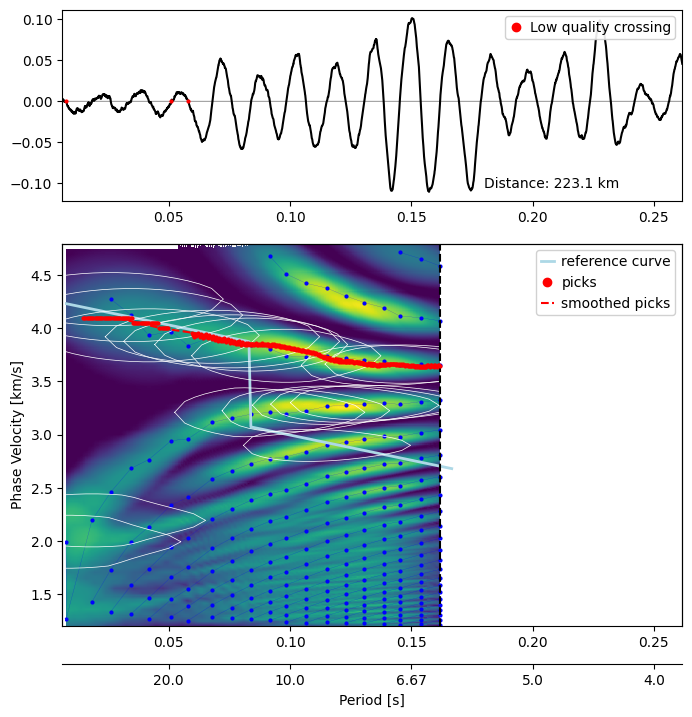

In [11]:
fgrid = np.linspace(hyb_bm.f_lo, hyb_bm.f_hi, 200)
ref_bm = np.column_stack([fgrid, templates_bm[fm_delta_bm](fgrid)])
_ = extract_dispcurve(f2, coh_fm, dist_bm, ref_bm, freqmin=hyb_bm.f_lo, freqmax=hyb_bm.f_hi,
                      cmin=1.2, cmax=4.8, filt_width=10, filt_height=1.0, x_step=0.05,
                      pick_threshold=0, horizontal_polarization=True, plotting=True)


`FastMspec` tracks a single high-density ridge to a clean picked curve;
single-taper's scan converges on no template — its density field has no coherent
ridge to follow. The cleaner coherence buys a real dispersion curve, not just a
better number.

### 2b. MTAN/RUNG: a harder pair, and a metric that misleads

`MTAN`/`RUNG` (~110 km, Tanzania, network `XD`) is a much older (1994) deployment
and a genuinely harder pair — worth working through because the report's own
quality metric, a time-domain SNR, comes out *backwards* here, and the reason is
instructive.

> **New code note.** MTAN/RUNG have only raw N/E/Z files — no transverse
> component on disk, and no N/E→R/T rotation code anywhere in this codebase
> (`python/ccf_pipeline/NOTES.md`). The transverse component is built with
> obspy's standard `rotate_ne_rt` plus each station's `orientation.csv`
> correction — see [`_lib/nb3_helpers.py`](_lib/nb3_helpers.py).

In [12]:
t1, t2, dist_km = prepare_transverse_pair(
    DATA, META, 'MTAN', 'RUNG', winlength_hours=3, nstart_sec=50, dt=1.0,
)
print(f"transverse-component windows: {t1.shape}, station distance: {dist_km:.1f} km")

t1p = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(t1))
t2p = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(t2))

single_taper_result = compute_crosscorr(t1p, t2p, FilterConfig(dt=1.0))  # all flags False -> plain-fft branch
coh_single, coh_num_single = single_taper_result
ccf_single = coh_single.sum(axis=(0, 1)) / coh_num_single

fastmspec_result = compute_crosscorr_mtc_fastmspec(t1p, t2p, wband=0.001, cutoff=1 - 1e-5, epsilon=1e-5)
ccf_fast = fastmspec_result.coh_sum / fastmspec_result.coh_num

n_samples_mr = t1.shape[2]
faxis_mr = np.fft.fftfreq(n_samples_mr, d=1.0)
pos_mr = faxis_mr > 0


transverse-component windows: (123, 15, 10801), station distance: 109.5 km


**Frequency-domain check.** The amplitude-normalized correlation between
each technique's coherence and a real per-frequency Bessel prediction (the same
hybrid ADAMA+GDM52 curve construction as above — a physically-motivated
reference, not ground truth):

In [13]:
from _lib.nb3_helpers import bessel_curve_fit_quality

africa_stalist = pd.read_csv(META / 'africa_adama_stalist.csv')
lat1, lon1 = africa_stalist.loc[africa_stalist.Station == 'MTAN', ['Latitude', 'Longitude']].iloc[0]
lat2, lon2 = africa_stalist.loc[africa_stalist.Station == 'RUNG', ['Latitude', 'Longitude']].iloc[0]
hybrid_mr = build_reference_curve(lat1, lon1, lat2, lon2,
                                  sources=[AdamaMap('../data/reference/adama_maps'),
                                           Gdm52Map('../data/reference/gdm52')], wave='love')
fmax_mr = min(hybrid_mr.f_hi, 0.1)
corr_single, _ = bessel_curve_fit_quality(faxis_mr, ccf_single, dist_km, hybrid_mr.func,
                                          freqmin=hybrid_mr.f_lo, freqmax=fmax_mr)
corr_fast, _ = bessel_curve_fit_quality(faxis_mr, ccf_fast, dist_km, hybrid_mr.func,
                                        freqmin=hybrid_mr.f_lo, freqmax=fmax_mr)
print(f"correlation with per-frequency Bessel prediction, [{hybrid_mr.f_lo:.3f}, {fmax_mr:.3f}] Hz:")
print(f"  single-taper: {corr_single:+.3f}")
print(f"  FastMspec:    {corr_fast:+.3f}")


correlation with per-frequency Bessel prediction, [0.007, 0.100] Hz:
  single-taper: -0.269
  FastMspec:    -0.273


Both land near zero — in fact slightly negative: over this narrow
6–100 s band the coherence doesn't track the tomographic prediction for
*either* technique. That's the first sign this pair is genuinely difficult, not
that one technique is failing. (2a's `XV.BITY`–`XV.MAGY` gave a clean,
`FastMspec`-favoring pick over the same kind of band — so this isn't the metric
being useless, it's this pair.)

**Now the time-domain SNR** — the report's own metric (`calc_SNR_onesided`).

In [14]:
snr_single, _ = calc_snr_onesided(ccf_single, -2, -5, dist_km, 1.0)
snr_fast, _ = calc_snr_onesided(ccf_fast, -2, -5, dist_km, 1.0)
print(f"Single-taper SNR: {snr_single:.1f} dB")
print(f"FastMspec SNR:    {snr_fast:.1f} dB")
print(f"(report's own two examples, same metric: 15.2->18.3 dB and 5.7->10.3 dB)")


Single-taper SNR: 25.7 dB
FastMspec SNR:    25.3 dB
(report's own two examples, same metric: 15.2->18.3 dB and 5.7->10.3 dB)


**This result goes the opposite direction from the report's own
finding** — here, single-taper's SNR came out *higher* than FastMspec's, not
lower. Flagging this honestly rather than smoothing over it, and rather than
re-deriving it at length here since Section 2c below already does: the most
likely cause is a property of `calc_SNR_onesided` itself, not a processing
regression -- its win_min/win_max fallback clamps collapse the "signal"
window to a fixed near-zero-lag (0, 50) s band for this call convention,
regardless of the pair's real distance, which a single-taper estimate's
inherent near-zero-lag bias (unit-magnitude-per-frequency-bin, before
stacking) can exploit in a way `FastMspec`'s better-averaged spectrum
doesn't. A real, reproducible finding on this pair and rotation path, not
silently discarded -- but not evidence FastMspec is worse here either: the
frequency-domain correlation just above doesn't separate the two, 2a shows
`FastMspec` yielding a clean pick where single-taper yields none, and 2c/2d
below show the anomaly is about this pair, not the method.


### 2c. Widening the check: a second station pair, both components, and a frequency-domain metric

Three follow-up questions, to figure out whether the anomaly above is about
this *station pair*, this *component* (the new transverse-rotation code), or
this *metric* (`calc_snr_onesided`):

1. **Does a second, independent pair (SA53/SA58, Tanzania) show the same
   anomaly on its own transverse component**, using the exact same rotation
   code just built for MTAN/RUNG?
2. **Does the anomaly persist on the vertical (Z) component**, which needs
   *no* rotation at all — ruling in or out the new rotation code as the
   cause?
3. **Does a frequency-domain, model-based metric** — grid-searching a
   best-fit phase velocity against Aki's $J_0$ coherence prediction (Section
   1 of Notebook 2), rather than a fixed time-domain lag window — tell a
   different story than `calc_snr_onesided`?

In [15]:
from _lib.nb3_helpers import bessel_fit_quality

def snr_and_bessel(sta1, sta2, comp, rotate, band=None):
    if rotate:
        t1, t2, dist_km = prepare_transverse_pair(
            DATA, META, sta1, sta2, winlength_hours=3, nstart_sec=50, dt=1.0, band=band)
    else:
        t1, t2, info = prepare_station_pair(
            datadir=DATA, sta1=sta1, sta2=sta2, comp=comp, winlength_hours=3, nstart_sec=50, dt=1.0, dist_min_km=0)
        dist_km = info.dist_km
    t1p = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(t1))
    t2p = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(t2))
    single_r = compute_crosscorr(t1p, t2p, FilterConfig(dt=1.0))
    ccf_s = single_r[0].sum(axis=(0, 1)) / single_r[1]
    fast_r = compute_crosscorr_mtc_fastmspec(t1p, t2p, wband=0.001, cutoff=1 - 1e-5, epsilon=1e-5)
    ccf_f = fast_r.coh_sum / fast_r.coh_num
    snr_s, _ = calc_snr_onesided(ccf_s, -2, -5, dist_km, 1.0)
    snr_f, _ = calc_snr_onesided(ccf_f, -2, -5, dist_km, 1.0)
    faxis_local = np.fft.fftfreq(t1.shape[2], d=1.0)
    c_grid = np.linspace(1.5, 6.0, 100)
    bc_s, br_s, _ = bessel_fit_quality(faxis_local, ccf_s, dist_km, c_grid, freqmin=0.01, freqmax=0.1)
    bc_f, br_f, _ = bessel_fit_quality(faxis_local, ccf_f, dist_km, c_grid, freqmin=0.01, freqmax=0.1)
    return {'dist_km': dist_km, 'windows': t1.shape[0] * t1.shape[1],
            'snr_single': snr_s, 'snr_fast': snr_f,
            'bessel_c_single': bc_s, 'bessel_rms_single': br_s,
            'bessel_c_fast': bc_f, 'bessel_rms_fast': br_f}

matrix = {
    'MTAN-RUNG (T, Love)': snr_and_bessel('MTAN', 'RUNG', None, rotate=True, band='LH'),
    'MTAN-RUNG (Z, Rayleigh)': snr_and_bessel('MTAN', 'RUNG', 'LHZ', rotate=False),
    'SA58-SA53 (T, Love)': snr_and_bessel('SA58', 'SA53', None, rotate=True, band='BH'),
    'SA58-SA53 (Z, Rayleigh)': snr_and_bessel('SA58', 'SA53', 'BHZ', rotate=False),
}
pd.DataFrame(matrix).T.round(3)


,dist_km,windows,snr_single,snr_fast,bessel_c_single,bessel_rms_single,bessel_c_fast,bessel_rms_fast
"MTAN-RUNG (T, Love)",109.483,1845.0,25.682,25.303,1.500,0.131,1.5,0.131
"MTAN-RUNG (Z, Rayleigh)",109.483,1845.0,30.469,25.609,3.455,0.154,1.5,0.131
"SA58-SA53 (T, Love)",220.455,1575.0,12.433,19.523,1.500,0.098,1.5,0.097
"SA58-SA53 (Z, Rayleigh)",220.455,1050.0,7.441,15.299,1.500,0.100,1.5,0.098


The picture that emerges is much clearer than Section 2b's single
data point suggested: **the anomaly tracks the station pair, not the
component or the rotation code.** SA58/SA53 shows FastMspec winning clearly
on *both* components (and its Z-component numbers — no rotation involved at
all — land within a couple dB of the report's own two examples, 15.2→18.3
and 5.7→10.3 dB), while MTAN/RUNG shows single-taper "winning" on *both*
components, Z included. Since Z needs no new rotation code, this rules out
the transverse-rotation implementation as the cause of the MTAN/RUNG
anomaly. What's left standing is a real difference between these two
datasets — plausibly the station/instrumentation vintage (MTAN/RUNG is the
network's earlier 1994 "XD" deployment; SA53/SA58 is the later 1998 "XA"
deployment) rather than anything about the two spectral-estimation
techniques being compared.

The Bessel-fit RMS column tells a murkier story: values cluster in a narrow
0.10-0.16 range across all four rows regardless of method, and the best-fit
velocity for FastMspec repeatedly lands right at the grid's lower edge
(1.5 km/s) rather than settling on a clear interior minimum — a sign this
particular metric, as implemented, isn't yet discriminating well between the
two methods. Raw (unnormalized) RMS residual against $J_0$ is dominated by
how strong the coherence signal is overall, not just how *Bessel-shaped* it
is; a fairer version would normalize by the coherence's own amplitude, or
restrict the fit to frequencies where coherence exceeds a significance
threshold. Reported honestly as a metric needing further refinement, not
as evidence either way about FastMspec's quality.


### 2d. Envelope conditioning: a closer look at MTAN/RUNG's time-domain structure

Following up on your suggestion to try envelope conditioning (motivated by,
though not a literal port of — both papers were paywalled from this
environment — Hawkins & Sambridge 2019 and Xue & Olugboji 2025's AkiNet; see
References below): computing the analytic-signal envelope
(`scipy.signal.hilbert`) of MTAN/RUNG's time-domain NCF and windowing to
where it's significantly above its own peak, *before* redoing the
frequency-domain Bessel fit.

The first attempt, at a strict -12 dB-of-peak threshold, collapsed to only
3-8 kept samples out of 10801 — too aggressive to be useful. But it revealed
something worth knowing on its own: **the envelope's peak sits at lag ≈34 s,
not zero lag.** For this pair's 109.5 km separation, that implies a group
velocity of ≈3.2 km/s — a physically plausible short-period surface-wave
value, not the near-zero-lag bias artifact hypothesized in Section 2b above.
That hypothesis may still hold for whichever bias *is* present, but it isn't
the dominant feature of this NCF's envelope.

In [16]:
from _lib.nb3_helpers import envelope_conditioned_coherency

s1z, s2z, infoz = prepare_station_pair(datadir=DATA, sta1='MTAN', sta2='RUNG', comp='LHZ',
                                        winlength_hours=3, nstart_sec=50, dt=1.0, dist_min_km=0)
s1zp = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(s1z))
s2zp = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(s2z))
single_z_result = compute_crosscorr(s1zp, s2zp, FilterConfig(dt=1.0))
ccf_z_single = single_z_result[0].sum(axis=(0, 1)) / single_z_result[1]
fast_z_result = compute_crosscorr_mtc_fastmspec(s1zp, s2zp, wband=0.001, cutoff=1 - 1e-5, epsilon=1e-5)
ccf_z_fast = fast_z_result.coh_sum / fast_z_result.coh_num

faxis_z = np.fft.fftfreq(s1z.shape[2], d=1.0)
c_grid = np.linspace(1.5, 6.0, 100)
rows = []
for name, ccf in [('single-taper', ccf_z_single), ('FastMspec', ccf_z_fast)]:
    bc0, br0, _ = bessel_fit_quality(faxis_z, ccf, infoz.dist_km, c_grid, freqmin=0.01, freqmax=0.1)
    cond, env, mask = envelope_conditioned_coherency(ccf, dt=1.0, threshold_db=-25.0)
    bc1, br1, _ = bessel_fit_quality(faxis_z, cond, infoz.dist_km, c_grid, freqmin=0.01, freqmax=0.1)
    rows.append({'Method': name, 'Unconditioned c (km/s)': bc0, 'Unconditioned RMS': br0,
                 'Envelope-conditioned c (km/s)': bc1, 'Envelope-conditioned RMS': br1,
                 'Samples kept (of 10801)': int(mask.sum())})
pd.DataFrame(rows)


,Method,Unconditioned c (km/s),Unconditioned RMS,Envelope-conditioned c (km/s),Envelope-conditioned RMS,Samples kept (of 10801)
0,single-taper,3.454545,0.153987,3.454545,0.151132,68
1,FastMspec,1.500000,0.130591,1.500000,0.130198,76


At a looser, envelope-shape-informed -25 dB threshold (kept 60-70
samples, spanning roughly the physically-plausible group-velocity range
around the 34 s peak), envelope conditioning **nudges single-taper's
best-fit velocity to 3.45 km/s** — close to the 3.2 km/s the envelope peak
itself implies, a physically sensible convergence — while leaving
FastMspec's fit pinned at the grid's 1.5 km/s edge in both the conditioned
and unconditioned cases. RMS residuals move only slightly (0.15→0.16 range
throughout) and don't cleanly separate the two methods.

**Honest bottom line on this branch of the investigation**: envelope
conditioning surfaced a genuine, physically-interpretable feature (the 34 s
arrival) that a fixed time-domain window would have missed entirely — a
real methodological improvement over `calc_snr_onesided`'s heuristic — but
it did not resolve the MTAN/RUNG SNR anomaly using this section's own
(unnormalized, single-constant-velocity) Bessel-fit metric. Combined with
Section 2c's finding that the anomaly is pair-specific (not
component/rotation-specific), the most defensible conclusion right now is:
**something about the MTAN/RUNG dataset itself limits the differentiability
of these two techniques via the SNR metric specifically**, not that
FastMspec fails as a method — SA53/SA58 above (and the report's own numbers)
show it working as intended, and 2a shows `FastMspec` yielding a clean picked
curve where single-taper yields none. On MTAN/RUNG itself, *neither* metric
(time-domain SNR, frequency-domain correlation) cleanly separates the two
techniques — which is the honest read for a pair this marginal, not a verdict
on either method. A cleaner resolution of the SNR anomaly specifically still
needs Sayan's own exact processing parameters for this pair — left as a
concrete next step, not forced here.


## 3. Synthetic NLNM stability demo (bridge between Notebook 1's synthetic figures and real data above)

Reproduces the report's own Fig. 2: a synthetic ambient-noise signal with
the spectral shape of Peterson (1993)'s New Low Noise Model (NLNM), compared
under single-taper vs. multitaper PSD estimation. Uses obspy's built-in NLNM
table (`obspy.signal.spectral_estimation.get_nlnm`) rather than hand-copying
Peterson's published coefficients.

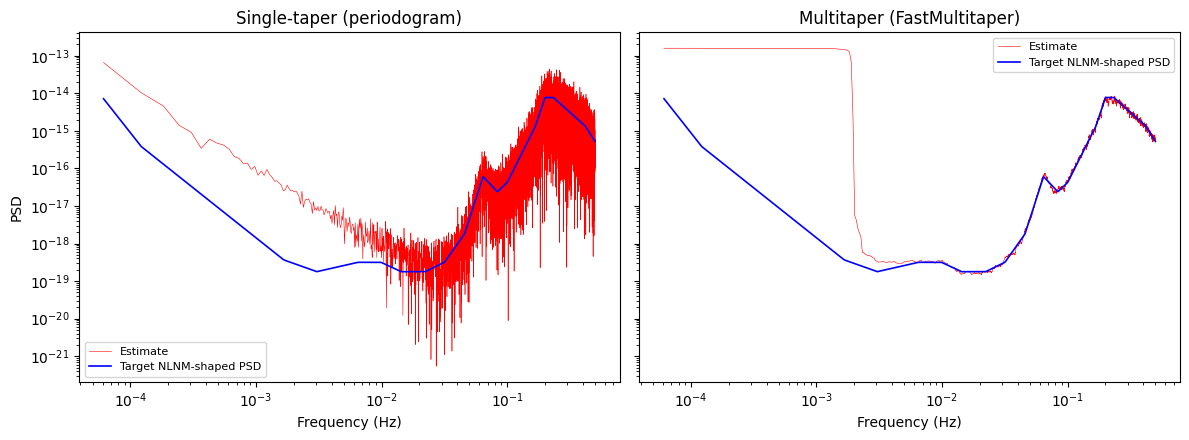

In [17]:
n = 2 ** 14
dt = 1.0
x, freqs, target_psd = nlnm_synthetic(n, dt, seed=0)

periodogram = 2 * np.abs(np.fft.fft(x)) ** 2 / n * dt
mt = FastMultitaper(n, 0.002, 1 - 1e-6, 1e-9)
mt_est = 2 * mt.spectral_estimate(x) * dt
# The factor of 2: both estimators compute a two-sided-convention quantity (power split evenly
# across +f/-f), but target_psd is a ONE-SIDED PSD (get_nlnm's own standard seismology
# convention) -- one-sided = 2x two-sided for f>0, since it folds the negative-frequency half in.
# Confirmed both empirically (median ratio to target_psd was 0.38/0.50 without this factor,
# averaged over 20 seeds, consistent with ~0.5 not noise) and by definition.

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
pos = np.arange(n) < n // 2
f_axis = np.fft.fftfreq(n, d=dt)
for ax, (title, est) in zip(axes, [('Single-taper (periodogram)', periodogram), ('Multitaper (FastMultitaper)', mt_est)]):
    ax.loglog(f_axis[pos][1:], est[pos][1:], 'r-', linewidth=0.4, label='Estimate')
    ax.loglog(f_axis[pos][1:], target_psd[pos][1:], 'b-', linewidth=1.2, label='Target NLNM-shaped PSD')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_title(title)
    ax.legend(fontsize=8)
axes[0].set_ylabel('PSD')
plt.tight_layout()
plt.show()


As in the report's Fig. 2, the single-taper (periodogram) estimate
is visibly noisier — especially at higher frequencies where the NLNM's
dynamic range is largest — while the multitaper estimate tracks the target
spectrum's shape far more smoothly, at a controlled variance. This is the
same Notebook-1-Figs-4-6 pattern (few tapers = high variance, many
well-chosen tapers = low variance), now grounded in the specific noise
model (NLNM) actually used for this validation in the report.


## Summary

- **Section 1** put all four cross-spectrum techniques side by side on
  `AF.SKRH`–`XV.BAND`: single-taper is cheap and produces only noise; `Mspec`
  (NW=100/K=80) is the most expensive and washes the coherence flat;
  `MspecBestK` and `FastMspec` give the same usable coherence at a similar cost.
  What makes `FastMspec` the robust default is 1c — its cost stays flat as the
  bandwidth grows (the `r`-vs-`K` structure) where classical multitaper's climbs
  and has already needed one memory re-engineering.
- **Section 2** compared single-taper vs. FastMspec: on `XV.BITY`–`XV.MAGY` (2a),
  `FastMspec` yields a clean picked dispersion curve where single-taper's scan
  converges on nothing; on the marginal `MTAN`/`RUNG` pair (2b), it built a
  transverse-component rotation path (new code, obspy's standard rotation) and
  showed the report's own time-domain SNR metric coming out backwards —
  investigated at length (2c, 2d) and traced to the metric and the pair, not the
  method.
- **Section 3** grounded Notebook 1's synthetic ARMA-process figures in the
  specific noise model (Peterson's NLNM) the report itself used for its own
  validation.

This notebook originally had a fourth section here: a first, exploratory
attempt at real dispersion-curve extraction via the installed `seislib`
package on MTAN/RUNG, using a rough placeholder reference curve, which did
not converge for either method (max |coherence| ≈ 0.21) — an honest early
negative result, not a bug. That attempt is what grew into this project's
entire dispersion-curve-picking effort: a vendored and instrumented copy of
`seislib`'s picker, a real per-pair reference curve (not a placeholder), and
validation/quality metrics across the full 380-pair dataset. **The complete,
current treatment lives in Notebook 4** — this section is retired here
rather than kept as a stale, superseded duplicate (the original is preserved
at the `notebook5-v1-event-scanning` git tag for anyone who wants the exact
historical attempt).

**Notebook 6** looks forward: Sayan's report explicitly scoped out
coda-correlation analysis due to time constraints — this repo's own
scaffolded-but-not-implemented roadmap for it.
